In [2]:
import numpy as np
import gudhi as gd
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# **Función para Calcular el Umbral Bootstrap C_alpha**

In [3]:
def umbral_bootstrap(X, alpha=0.05, n_iteraciones=500):
    #Calcular diagrama de dimensión cero
    rips_complex = gd.RipsComplex(points=X)
    simplex_tree = rips_complex.create_simplex_tree(max_dimension=1)
    persistencia = simplex_tree.persistence()
    diag_orig = simplex_tree.persistence_intervals_in_dimension(0)

    # Filtrar el punto que vive para siempre para el cálculo de distancias
    diag_orig = diag_orig[np.isfinite(diag_orig[:, 1])]

    bottleneck_dist = []
    n_samples=int(len(X)*0.8)
    
    # Bucle de Bootstrap
    for i in range(n_iteraciones):
        # Submuestreo
        X_sub = resample(X, n_samples=n_samples, replace=True)

        rips_sub = gd.RipsComplex(points=X_sub)
        st_sub = rips_sub.create_simplex_tree(max_dimension=1)
        st_sub.persistence()

        diag_sub = st_sub.persistence_intervals_in_dimension(0)
        diag_sub = diag_sub[np.isfinite(diag_sub[:, 1])]

        #Distancia de Bottleneck
        d = gd.bottleneck_distance(diag_orig, diag_sub)
        bottleneck_dist.append(d)

    # Tomar el percentil (1 - alpha)
    c_alpha = np.percentile(bottleneck_dist, (1 - alpha) * 100)
    return c_alpha, diag_orig

# **Ejemplo**

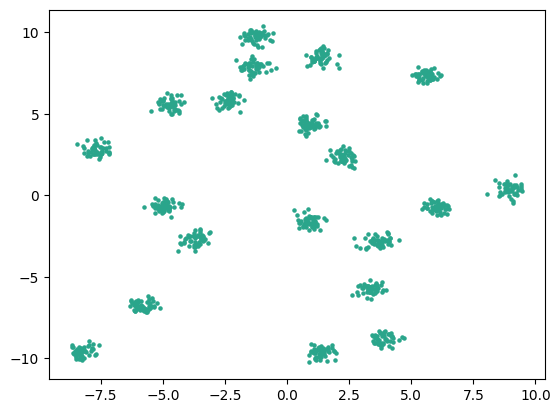

In [6]:
Datos,y=make_blobs(n_samples=1000, centers=20, n_features=3, random_state=0, cluster_std=0.3)
plt.figure()
plt.scatter(Datos[:,0],Datos[:,1], s=5, color='#2AA58B')
plt.show()

In [8]:
umbral, diagrama= umbral_bootstrap(Datos, alpha=0.01)
print(umbral)

puntos_significativos=[x for x in diagrama[:,1] if x>2*umbral]
print(f"Cantidad de puntos significativos: {len(puntos_significativos)}")

0.584375059503463
Cantidad de puntos significativos: 19
